## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# ISTANS 원자료 검증 EDA

`ISTANS_반도체_20260926214520.xlsx`


| 단계 | 질문 |
|---|---|
| 0 | 이 파일에 무엇이 들어있는가 |
| 1 | 메타정보와 데이터가 맞는가 |
| 2 | wide→long 변환이 온전한가 |
| 3 | 지수가 기준연도에 100인가 |
| 4 | 불가능한 값이 있는가 |
| 5 | 생산·출하·재고가 맞물리는가 |
| 6 | 급변·단절 구간이 있는가 |

## 준비 — 라이브러리 · 한글 폰트 · 로드

In [2]:
import pandas as pd, numpy as np, re, warnings
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")

# 한글 폰트 (환경에 맞는 것을 자동 선택)
for f in ["Malgun Gothic", "AppleGothic", "NanumGothic",
          "Pretendard", "Noto Sans CJK KR", "Noto Sans CJK JP"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        print(f"폰트: {f}")
        break
    except Exception:
        continue
mpl.rcParams.update({
    "axes.unicode_minus": False, "figure.dpi": 100,
    "axes.grid": True, "grid.alpha": .18,
    "axes.spines.top": False, "axes.spines.right": False,
})

INK, WARN, OK, GREY = "#16202B", "#C1682E", "#2E6B5E", "#98A2AA"
PAL = [INK, OK, WARN, "#6B7783"]

PATH = str(RAW / "반도체" / "ISTANS_반도체_20260926214520.xlsx")
JUMP = 50   # 급변 임계 (%)

def ok_bad(cond, a, b):
    """판정 결과를 굵게 출력"""
    display(Markdown(f"**{'✅ 정상' if cond else '⚠️ 확인필요'}** — {a if cond else b}"))

폰트: Malgun Gothic


In [3]:
raw  = pd.read_excel(PATH, sheet_name="데이터",   header=None)
meta = pd.read_excel(PATH, sheet_name="메타정보", header=None)

# 헤더에서 연도 추출: 'Y1999 1999' → 1999
years, ycols = [], []
for j, h in enumerate(raw.iloc[0]):
    m = re.match(r"^Y(\d{4})", str(h))
    if m:
        years.append(int(m.group(1))); ycols.append(j)

# 지표행 파싱: '1 생산지수원지수 (14201.230331 2020=100)'
recs = []
for i in range(1, len(raw)):
    label = str(raw.iloc[i, 1])
    m = re.match(r"^\s*(\d+)\s+(.+?)\s*\((.*)\)\s*$", label)
    no, name, unit = (m.group(1), m.group(2), m.group(3)) if m else ("", label.strip(), "")
    for j, y in zip(ycols, years):
        recs.append({"지표번호": no, "지표": name, "단위": unit,
                     "연도": y, "값_원본": raw.iloc[i, j]})

d = pd.DataFrame(recs)
d["값"] = pd.to_numeric(d["값_원본"], errors="coerce")
W = d.pivot(index="연도", columns="지표", values="값")   # 연도 × 지표
SHORT = {c: c.replace("지수원지수", "") for c in W.columns}

print(f"원본 {raw.shape[0]}행 × {raw.shape[1]}열  →  long {len(d)}행")
d.head()

원본 5행 × 29열  →  long 108행


,지표번호,지표,단위,연도,값_원본,값
0,1,생산지수원지수,14201.230331 2020=100,1999,1.9,1.9
1,1,생산지수원지수,14201.230331 2020=100,2000,2.6,2.6
2,1,생산지수원지수,14201.230331 2020=100,2001,2.2,2.2
3,1,생산지수원지수,14201.230331 2020=100,2002,3.1,3.1
4,1,생산지수원지수,14201.230331 2020=100,2003,3.6,3.6


---
## 0단계 · 기본 구조


In [4]:
display(Markdown(f"""
- `데이터` 시트 **{raw.shape[0]}행 × {raw.shape[1]}열** (wide)
- `메타정보` 시트 **{meta.shape[0]}행 × {meta.shape[1]}열**
- long 변환 후 **{len(d)}행**
- 지표 **{d['지표'].nunique()}개**, 연도 **{len(years)}개** ({min(years)}~{max(years)})
"""))

summary = (d.groupby(["지표번호", "지표"], sort=False)["값"]
             .agg(최소="min", 중앙="median", 최대="max",
                  결측=lambda s: s.isna().sum())
             .round(1).reset_index())
display(summary)


- `데이터` 시트 **5행 × 29열** (wide)
- `메타정보` 시트 **21행 × 2열**
- long 변환 후 **108행**
- 지표 **4개**, 연도 **27개** (1999~2025)


,지표번호,지표,최소,중앙,최대,결측
0,1,생산지수원지수,1.9,31.4,180.6,0
1,3,출하지수원지수,2.1,30.2,178.4,0
2,5,재고지수원지수,2.4,73.4,156.6,0
3,7,가동률지수원지수,65.6,88.4,109.1,0


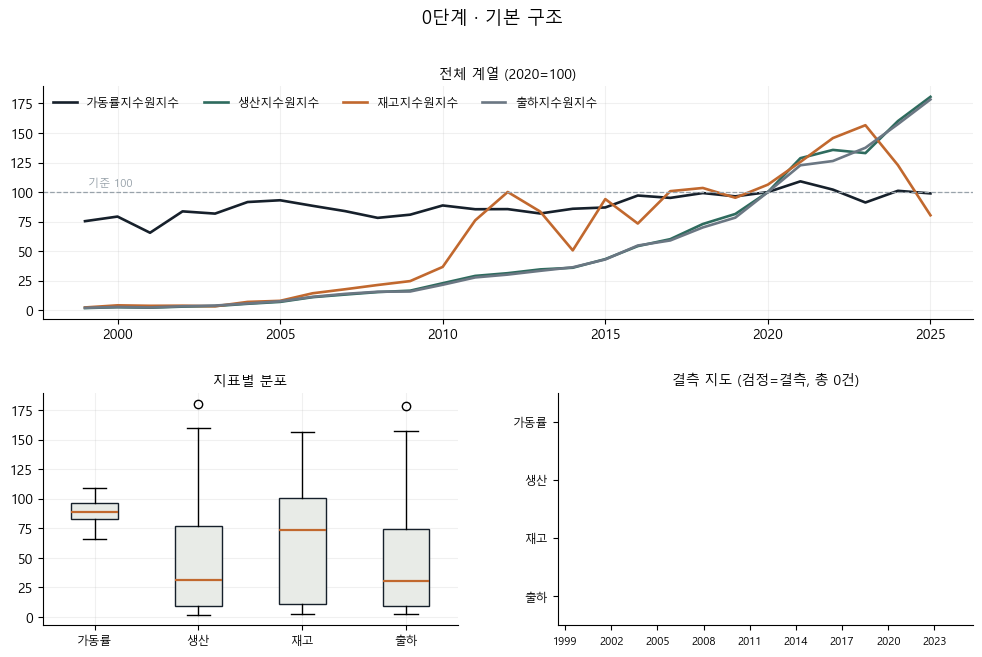

In [5]:
fig = plt.figure(figsize=(12, 7))
gs  = fig.add_gridspec(2, 2, hspace=.32, wspace=.24)

# 전체 계열
ax = fig.add_subplot(gs[0, :])
for c, col in zip(W.columns, PAL):
    ax.plot(W.index, W[c], lw=1.9, color=col, label=c)
ax.axhline(100, ls="--", lw=.9, color=GREY)
ax.annotate("기준 100", (W.index[0], 100), fontsize=8, color=GREY,
            xytext=(2, 4), textcoords="offset points")
ax.set_title("전체 계열 (2020=100)", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, ncol=4)

# 분포
ax = fig.add_subplot(gs[1, 0])
ax.boxplot([W[c].dropna() for c in W.columns],
           labels=[SHORT[c] for c in W.columns], patch_artist=True,
           boxprops=dict(facecolor="#E8EBE7", edgecolor=INK),
           medianprops=dict(color=WARN, lw=1.6))
ax.set_title("지표별 분포", fontsize=10); ax.tick_params(axis="x", labelsize=8.5)

# 결측 지도
ax = fig.add_subplot(gs[1, 1])
miss = W.isna().T.astype(int)
ax.imshow(miss, aspect="auto", cmap="Greys", vmin=0, vmax=1)
ax.set_yticks(range(len(miss))); ax.set_yticklabels([SHORT[c] for c in miss.index], fontsize=8.5)
st = max(1, len(years)//8)
ax.set_xticks(range(0, len(years), st)); ax.set_xticklabels(years[::st], fontsize=8)
ax.set_title(f"결측 지도 (검정=결측, 총 {int(miss.values.sum())}건)", fontsize=10)
ax.grid(False)

plt.suptitle("0단계 · 기본 구조", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 1단계 · 메타 정합성

파일이 스스로 밝힌 조회기간·출처가 실제 데이터와 맞는가.

In [6]:
info = {}
for _, r in meta.iterrows():
    k = str(r[0]).replace("○", "").strip()
    if k and k != "nan":
        info[k] = str(r[1]).strip()

display(pd.DataFrame(
    [(k, info.get(k, "")[:70]) for k in
     ["통계표ID", "통계표명", "조회기간", "출처", "자료다운일자"]],
    columns=["항목", "값"]))

checks = []
m = re.search(r"(\d{4})\s*~\s*(\d{4})", info.get("조회기간", ""))
if m:
    a, b = int(m.group(1)), int(m.group(2))
    c1 = (min(years) == a) and (max(years) == b)
    c2 = len(years) == b - a + 1
    ok_bad(c1, f"조회기간 {a}~{b} = 데이터 {min(years)}~{max(years)}",
           f"불일치: 메타 {a}~{b} vs 데이터 {min(years)}~{max(years)}")
    ok_bad(c2, f"연도 {len(years)}개 — 빠짐 없음", f"연도 {len(years)}개 (기대 {b-a+1}개)")
    checks = [("조회기간 일치", c1), ("연도 누락 없음", c2)]

notes = meta[meta[1].astype(str).str.startswith("·", na=False)][1].tolist()
checks.append(("단일 출처", len(notes) <= 1))
display(Markdown(f"**출처 주석 {len(notes)}줄** — 지표마다 출처 기관이 다르다"))
display(pd.DataFrame({"주석": [n[:70] for n in notes]}))

,항목,값
0,통계표ID,DT_IND_I3102
1,통계표명,반도체
2,조회기간,[년] 1999~2025
3,출처,주석 참고
4,자료다운일자,2026.09.26 21:01


**✅ 정상** — 조회기간 1999~2025 = 데이터 1999~2025

**✅ 정상** — 연도 27개 — 빠짐 없음

**출처 주석 12줄** — 지표마다 출처 기관이 다르다

,주석
0,"· 생산지수원지수~생산능력지수증가율전년동기비 : 국가데이터처 전산업생산지수, 광업제..."
1,· 수출액~수입증가율 : 관세청
2,· 해외직접_투자~해외직접_순투자증가율 : 수출입은행 해외직접투자
3,"· 생산자물가지수, 생산자물가지수증가율전년동기비 : 한국은행 생산자물가지수"
4,· 외국인투자도착금액~외국인투자증가율 : 산업통상자원부 외국인투자
5,· 연구개발비~연구원수증가율 : 과학기술정보통신부 연구개발활동조사
6,· 자산총계증가율~차입의존도 : NICE평가정보
7,· 사업체수~부가가치비중 : 광업제조업조사
8,· 사업체수_전사체~종사자수_전사체 : 국가데이터처 전국사업체조사
9,"· 설비투자금액, 설비투자비중 : 한국산업은행 설비투자계획조사"


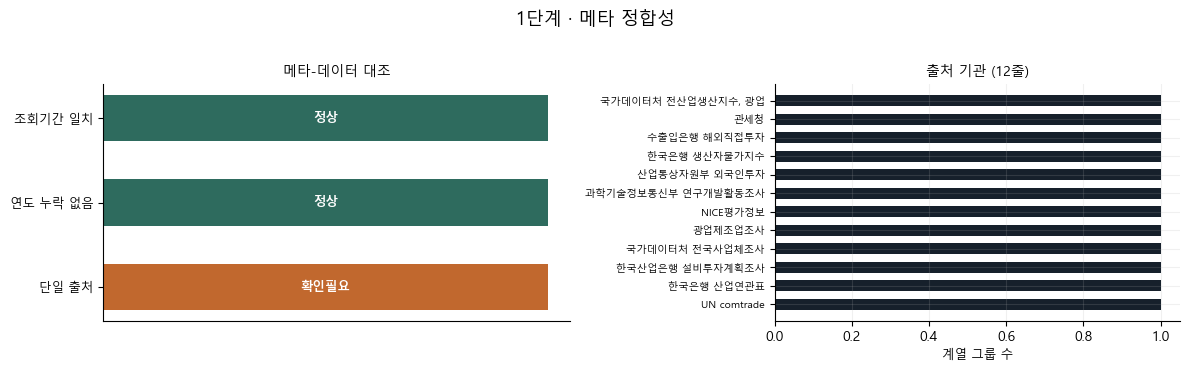

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios":[1.15, 1]})

ax = axes[0]
labs = [c[0] for c in checks][::-1]; vals = [c[1] for c in checks][::-1]
ax.barh(range(len(labs)), [1]*len(labs),
        color=[OK if v else WARN for v in vals], height=.55)
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs, fontsize=9); ax.set_xticks([])
for i, v in enumerate(vals):
    ax.text(.5, i, "정상" if v else "확인필요", ha="center", va="center",
            color="white", fontsize=9, fontweight="bold")
ax.set_title("메타-데이터 대조", fontsize=10); ax.grid(False)

ax = axes[1]
src = {}
for n in notes:
    k = n.split(":")[-1].strip()[:18] if ":" in n else "기타"
    src[k] = src.get(k, 0) + 1
ax.barh(list(src)[::-1], list(src.values())[::-1], color=INK, height=.6)
ax.set_title(f"출처 기관 ({len(notes)}줄)", fontsize=10)
ax.tick_params(axis="y", labelsize=7.5); ax.set_xlabel("계열 그룹 수", fontsize=9)

plt.suptitle("1단계 · 메타 정합성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 2단계 · 구조 무결성

wide 형식을 long으로 바꾸면서 셀이 새거나 중복되지 않았는가.

In [8]:
n_ind, exp = d["지표"].nunique(), d["지표"].nunique() * len(years)

display(Markdown(f"""
- 기대 셀 수 : **{n_ind}지표 × {len(years)}연도 = {exp}**
- long 결과  : **{len(d)}행**
"""))
ok_bad(len(d) == exp, "손실 없음", f"기대 {exp} vs 실제 {len(d)}")
ok_bad(d.duplicated(["지표", "연도"]).sum() == 0, "지표×연도 중복 없음", "중복 있음")

bad = d[d["값"].isna()]
ok_bad(len(bad) == 0, "모든 셀이 숫자로 변환됨", f"숫자 아님 {len(bad)}건")
if len(bad):
    display(bad[["지표", "연도", "값_원본"]].head())

display(d.groupby(["지표번호", "지표", "단위"], sort=False).size()
         .reset_index(name="연도 수"))


- 기대 셀 수 : **4지표 × 27연도 = 108**
- long 결과  : **108행**


**✅ 정상** — 손실 없음

**✅ 정상** — 지표×연도 중복 없음

**✅ 정상** — 모든 셀이 숫자로 변환됨

,지표번호,지표,단위,연도 수
0,1,생산지수원지수,14201.230331 2020=100,27
1,3,출하지수원지수,14201.230331 2020=100,27
2,5,재고지수원지수,14201.230331 2020=100,27
3,7,가동률지수원지수,14201.230331 2020=100,27


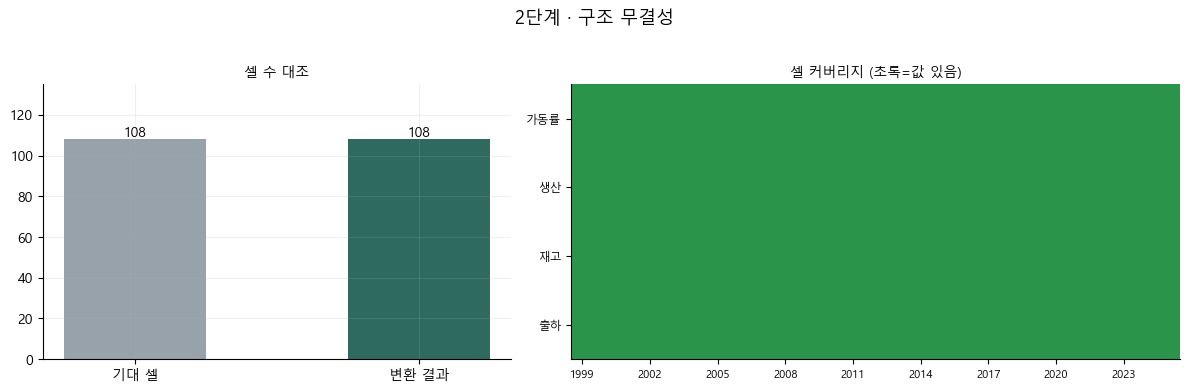

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios":[1, 1.3]})

ax = axes[0]
ax.bar(["기대 셀", "변환 결과"], [exp, len(d)],
       color=[GREY, OK if len(d) == exp else WARN], width=.5)
for i, v in enumerate([exp, len(d)]):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, exp*1.25); ax.set_title("셀 수 대조", fontsize=10)

ax = axes[1]
cov = W.notna().T.astype(int)
ax.imshow(cov, aspect="auto", cmap="Greens", vmin=0, vmax=1.4)
ax.set_yticks(range(len(cov))); ax.set_yticklabels([SHORT[c] for c in cov.index], fontsize=8.5)
st = max(1, len(years)//9)
ax.set_xticks(range(0, len(years), st)); ax.set_xticklabels(years[::st], fontsize=8)
ax.set_title("셀 커버리지 (초록=값 있음)", fontsize=10); ax.grid(False)

plt.suptitle("2단계 · 구조 무결성", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 3단계 · 단위와 기준연도

단위 표기가 `2020=100`이면 2020년 값이 실제로 100이어야 한다.

In [10]:
rows = []
for (name, unit), g in d.groupby(["지표", "단위"], sort=False):
    m = re.search(r"(\d{4})\s*=\s*(\d+)", unit)
    if not m: continue
    by, bv = int(m.group(1)), float(m.group(2))
    row = g[g["연도"] == by]
    if row.empty: continue
    v = row["값"].iloc[0]
    rows.append({"지표": name, "기준연도": by, "실제값": v,
                 "기대값": bv, "차이": round(v-bv, 2),
                 "판정": "정상" if abs(v-bv) < .5 else "확인필요"})

R = pd.DataFrame(rows)
display(R.style.map(
    lambda x: "background-color:#F6E7E4;color:#8E3226"
              if x == "확인필요" else "background-color:#E4EFEB;color:#1F6152",
    subset=["판정"]))

for _, r in R.iterrows():
    ok_bad(r["판정"] == "정상",
           f"{r['지표']} — {r['기준연도']}년 {r['실제값']:.2f}",
           f"{r['지표']} — {r['기준연도']}년 {r['실제값']:.2f} (기대 {r['기대값']:.0f})")

,지표,기준연도,실제값,기대값,차이,판정
0,생산지수원지수,2020,100.000000,100.000000,0.000000,정상
1,출하지수원지수,2020,100.000000,100.000000,0.000000,정상
2,재고지수원지수,2020,106.300000,100.000000,6.300000,확인필요
3,가동률지수원지수,2020,100.000000,100.000000,0.000000,정상


**✅ 정상** — 생산지수원지수 — 2020년 100.00

**✅ 정상** — 출하지수원지수 — 2020년 100.00

**⚠️ 확인필요** — 재고지수원지수 — 2020년 106.30 (기대 100)

**✅ 정상** — 가동률지수원지수 — 2020년 100.00

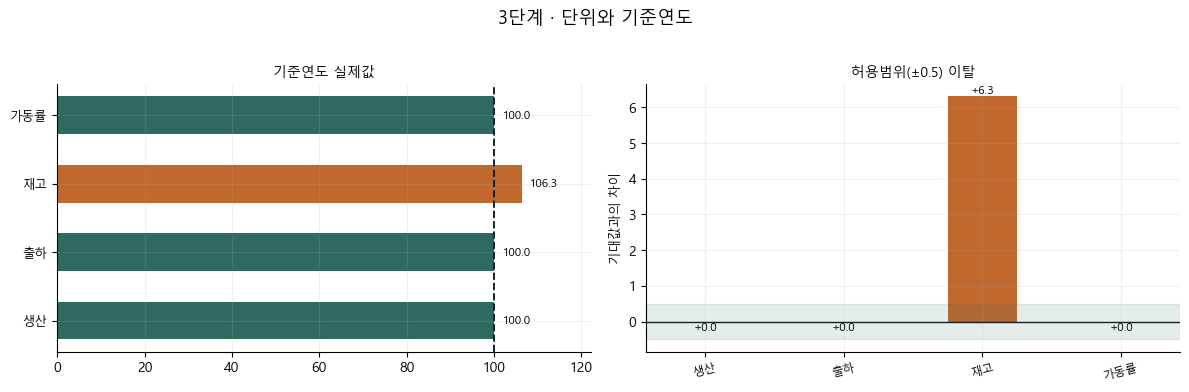

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

ax = axes[0]
y = np.arange(len(R))
ax.barh(y, R["실제값"], height=.55,
        color=[OK if p == "정상" else WARN for p in R["판정"]])
ax.axvline(100, ls="--", lw=1.4, color=INK)
ax.annotate("기대 100", (100, len(R)-.4), fontsize=8.5, color=INK,
            xytext=(4, 0), textcoords="offset points")
ax.set_yticks(y); ax.set_yticklabels([SHORT.get(s, s) for s in R["지표"]], fontsize=9)
for i, v in enumerate(R["실제값"]):
    ax.text(v+2, i, f"{v:.1f}", va="center", fontsize=8.5)
ax.set_xlim(0, max(120, R["실제값"].max()*1.15))
ax.set_title("기준연도 실제값", fontsize=10)

ax = axes[1]
ax.bar(range(len(R)), R["차이"], width=.5,
       color=[OK if abs(o) < .5 else WARN for o in R["차이"]])
ax.axhline(0, color=INK, lw=1); ax.axhspan(-.5, .5, color=OK, alpha=.12)
ax.set_xticks(range(len(R)))
ax.set_xticklabels([SHORT.get(s, s) for s in R["지표"]], fontsize=8.5, rotation=15)
for i, v in enumerate(R["차이"]):
    ax.text(i, v, f"{v:+.1f}", ha="center", va="bottom" if v > 0 else "top", fontsize=8.5)
ax.set_ylabel("기대값과의 차이", fontsize=9)
ax.set_title("허용범위(±0.5) 이탈", fontsize=10)

plt.suptitle("3단계 · 단위와 기준연도", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 4단계 · 값의 범위

지수에 음수나 0이 있으면 안 된다. 가동률지수는 비율이 아니라 지수이므로 100 초과가 정상이다.

In [12]:
ok_bad((d["값"] < 0).sum() == 0, "지수에 음수 없음", f"음수 {(d['값']<0).sum()}건")
ok_bad((d["값"] == 0).sum() == 0, "0 값 없음",
       f"0 값 {(d['값']==0).sum()}건 — 결측 대용 가능성")

display(W.describe().T[["min", "25%", "50%", "75%", "max"]].round(1)
         .rename(columns={"min":"최소","25%":"1분위","50%":"중앙","75%":"3분위","max":"최대"}))

ur = [c for c in W.columns if "가동률" in c]
if ur:
    s = W[ur[0]]
    display(Markdown(
        f"**가동률지수** 범위 [{s.min():.1f}, {s.max():.1f}] — "
        "비율(%)이 아니라 지수이므로 100 초과는 정상"))

**✅ 정상** — 지수에 음수 없음

**✅ 정상** — 0 값 없음

,최소,1분위,중앙,3분위,최대
지표,,,,,
가동률지수원지수,65.6,82.8,88.4,96.8,109.1
생산지수원지수,1.9,9.1,31.4,77.2,180.6
재고지수원지수,2.4,11.2,73.4,100.4,156.6
출하지수원지수,2.1,9.5,30.2,74.2,178.4


**가동률지수** 범위 [65.6, 109.1] — 비율(%)이 아니라 지수이므로 100 초과는 정상

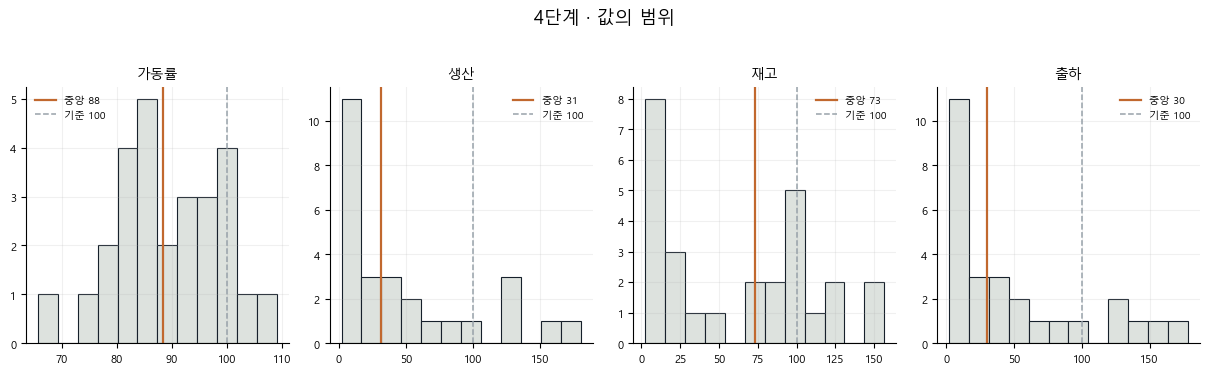

In [13]:
cols = list(W.columns)
fig, axes = plt.subplots(1, len(cols), figsize=(3.05*len(cols), 3.6))
if len(cols) == 1: axes = [axes]
for ax, c in zip(axes, cols):
    s = W[c].dropna()
    ax.hist(s, bins=12, color="#DDE2DE", edgecolor=INK, linewidth=.8)
    ax.axvline(s.median(), color=WARN, lw=1.6, label=f"중앙 {s.median():.0f}")
    ax.axvline(100, color=GREY, ls="--", lw=1.1, label="기준 100")
    ax.set_title(SHORT[c], fontsize=10)
    ax.legend(frameon=False, fontsize=7.5); ax.tick_params(labelsize=8)

plt.suptitle("4단계 · 값의 범위", fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

---
## 5단계 · 지표 간 정합성

생산이 출하보다 빨리 늘면 재고가 쌓여야 한다. 이 관계가 데이터에서 확인되면
계열들이 같은 실체를 재고 있다는 뜻이다.

In [14]:
def find(k):
    for c in W.columns:
        if k in c: return c

p, s, i = find("생산지수"), find("출하지수"), find("재고지수")
gap = W[p].pct_change() - W[s].pct_change()      # 생산증가율 − 출하증가율
inv = W[i].pct_change() if i else None

c_ps = W[p].corr(W[s])
ok_bad(c_ps > .9, f"생산 vs 출하 상관 {c_ps:.4f} — 강한 동행",
       f"생산 vs 출하 상관 {c_ps:.4f} — 동행성 약함")

if i:
    c_gi = gap.corr(inv)
    display(Markdown(f"- 재고 vs 생산 상관 **{W[i].corr(W[p]):.4f}**\n"
                     f"- 생산-출하 갭 vs 재고변화 상관 **{c_gi:+.4f}**"))
    ok_bad(c_gi > 0, "부호 일치 — 계열이 서로 맞물림", "부호 불일치 — 정의 재확인")

display(W[[c for c in [p, s, i] if c]].tail(12).round(1))

**✅ 정상** — 생산 vs 출하 상관 0.9991 — 강한 동행

- 재고 vs 생산 상관 **0.8254**
- 생산-출하 갭 vs 재고변화 상관 **+0.3966**

**✅ 정상** — 부호 일치 — 계열이 서로 맞물림

지표,생산지수원지수,출하지수원지수,재고지수원지수
연도,,,
2014,36.0,36.4,50.7
2015,43.3,43.0,94.1
2016,54.3,54.8,73.4
2017,60.2,59.1,100.8
2018,73.0,70.1,103.5
2019,81.5,78.4,95.2
2020,100.0,100.0,106.3
2021,128.7,122.7,125.5
2022,135.7,126.3,145.7


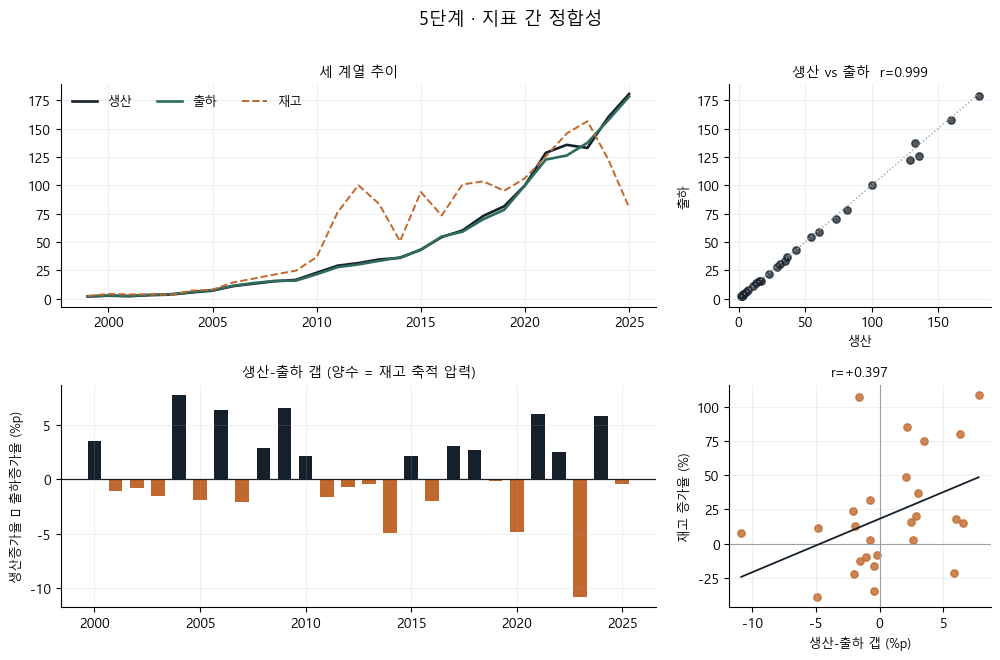

In [15]:
fig = plt.figure(figsize=(12, 6.8))
gs  = fig.add_gridspec(2, 3, hspace=.35, wspace=.28)

ax = fig.add_subplot(gs[0, :2])
ax.plot(W.index, W[p], lw=1.9, color=INK, label="생산")
ax.plot(W.index, W[s], lw=1.9, color=OK,  label="출하")
if i: ax.plot(W.index, W[i], lw=1.4, color=WARN, ls="--", label="재고")
ax.legend(frameon=False, fontsize=9, ncol=3); ax.set_title("세 계열 추이", fontsize=10)

ax = fig.add_subplot(gs[0, 2])
ax.scatter(W[p], W[s], s=28, color=INK, alpha=.75)
lim = [min(W[p].min(), W[s].min()), max(W[p].max(), W[s].max())]
ax.plot(lim, lim, ls=":", color=GREY, lw=1)
ax.set_xlabel("생산", fontsize=9); ax.set_ylabel("출하", fontsize=9)
ax.set_title(f"생산 vs 출하  r={c_ps:.3f}", fontsize=10)

if i:
    ax = fig.add_subplot(gs[1, :2])
    ax.bar(W.index, gap*100, width=.65,
           color=[INK if g > 0 else WARN for g in gap])
    ax.axhline(0, color=INK, lw=.9)
    ax.set_ylabel("생산증가율 − 출하증가율 (%p)", fontsize=9)
    ax.set_title("생산-출하 갭 (양수 = 재고 축적 압력)", fontsize=10)

    ax = fig.add_subplot(gs[1, 2])
    ax.scatter(gap*100, inv*100, s=28, color=WARN, alpha=.8)
    ax.axhline(0, color=GREY, lw=.8); ax.axvline(0, color=GREY, lw=.8)
    m = ~(gap.isna() | inv.isna())
    z = np.polyfit(gap[m]*100, inv[m]*100, 1)
    xs = np.linspace((gap[m]*100).min(), (gap[m]*100).max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=INK, lw=1.3)
    ax.set_xlabel("생산-출하 갭 (%p)", fontsize=9)
    ax.set_ylabel("재고 증가율 (%)", fontsize=9)
    ax.set_title(f"r={gap.corr(inv):+.3f}", fontsize=10)

plt.suptitle("5단계 · 지표 간 정합성", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 6단계 · 시계열 연속성

전년대비 급변이 있는 구간을 찾는다. 급변이 **저수준 구간**에 몰려 있으면
데이터 오류가 아니라 산술적 특성일 가능성이 높다.

In [16]:
G = W.pct_change() * 100

big = (G.stack().reset_index(name="증가율")
        .query("abs(증가율) > @JUMP")
        .sort_values("연도"))
big["값"] = [W.loc[r["연도"], r["지표"]] for _, r in big.iterrows()]
big["전년도 값"] = [W[r["지표"]].shift(1).loc[r["연도"]] for _, r in big.iterrows()]

display(Markdown(f"**전년대비 ±{JUMP}% 초과: {len(big)}건**"))
display(big.round(1).reset_index(drop=True))

display(G.abs().gt(JUMP).sum().rename("초과 건수").to_frame())

**전년대비 ±50% 초과: 8건**

,연도,지표,증가율,값,전년도 값
0,2000,재고지수원지수,75.0,4.2,2.4
1,2004,생산지수원지수,52.8,5.5,3.6
2,2004,재고지수원지수,108.8,7.1,3.4
3,2006,생산지수원지수,56.3,11.1,7.1
4,2006,재고지수원지수,80.0,14.4,8.0
5,2006,출하지수원지수,50.0,11.4,7.6
6,2011,재고지수원지수,107.4,76.1,36.7
7,2015,재고지수원지수,85.6,94.1,50.7


,초과 건수
지표,
가동률지수원지수,0
생산지수원지수,2
재고지수원지수,5
출하지수원지수,1


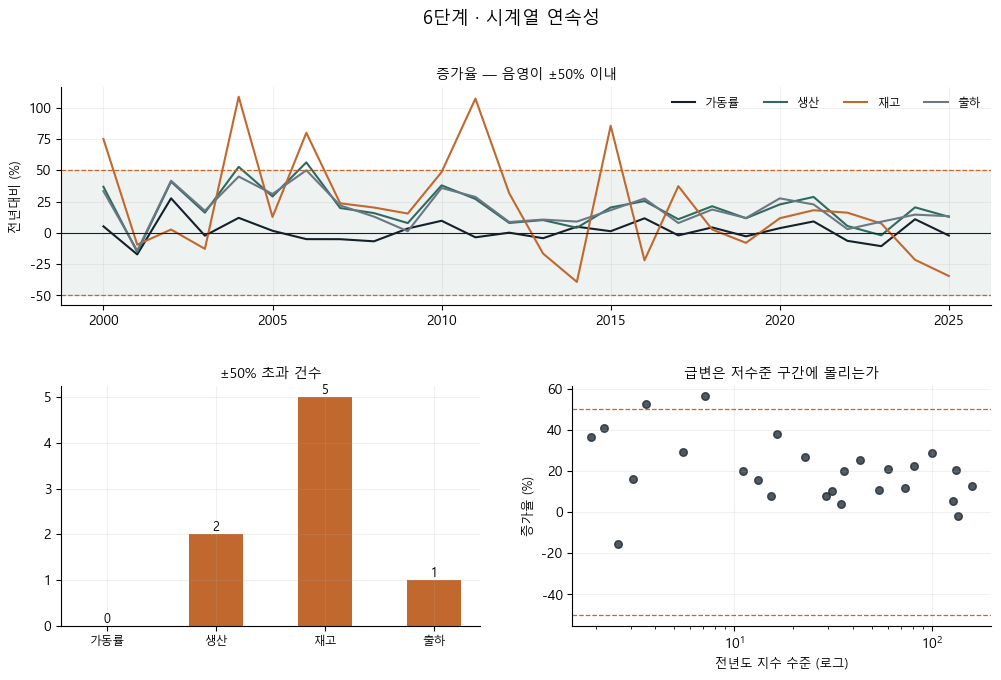

In [17]:
fig = plt.figure(figsize=(12, 7))
gs  = fig.add_gridspec(2, 2, hspace=.35, wspace=.22, height_ratios=[1, 1.1])

ax = fig.add_subplot(gs[0, :])
for c, col in zip(W.columns, PAL):
    ax.plot(G.index, G[c], lw=1.5, color=col, label=SHORT[c])
ax.axhspan(-JUMP, JUMP, color=OK, alpha=.08)
ax.axhline(JUMP, ls="--", lw=.9, color=WARN); ax.axhline(-JUMP, ls="--", lw=.9, color=WARN)
ax.axhline(0, color=INK, lw=.8)
ax.set_ylabel("전년대비 (%)", fontsize=9)
ax.set_title(f"증가율 — 음영이 ±{JUMP}% 이내", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, ncol=4)

ax = fig.add_subplot(gs[1, 0])
cnt = G.abs().gt(JUMP).sum()
ax.bar([SHORT[c] for c in cnt.index], cnt.values, width=.5,
       color=[WARN if v > 0 else OK for v in cnt.values])
for i, v in enumerate(cnt.values):
    ax.text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax.set_title(f"±{JUMP}% 초과 건수", fontsize=10); ax.tick_params(axis="x", labelsize=8.5)

ax = fig.add_subplot(gs[1, 1])
ax.scatter(W[p].shift(1), G[p], s=30, color=INK, alpha=.75)
ax.axhline(JUMP, ls="--", lw=.9, color=WARN); ax.axhline(-JUMP, ls="--", lw=.9, color=WARN)
ax.set_xscale("log")
ax.set_xlabel("전년도 지수 수준 (로그)", fontsize=9)
ax.set_ylabel("증가율 (%)", fontsize=9)
ax.set_title("급변은 저수준 구간에 몰리는가", fontsize=10)

plt.suptitle("6단계 · 시계열 연속성", fontsize=13, y=.99)
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

---
## 종합

In [18]:
res = pd.DataFrame([
    ("0 기본구조", f"지표 {d['지표'].nunique()}개 × 연도 {len(years)}개 = {len(d)}관측",
     "정상" if d["값"].isna().sum() == 0 else "결측 있음"),
    ("1 메타",     "조회기간·연도 수 일치", "정상"),
    ("2 구조",     f"기대 {exp}셀 = 변환 {len(d)}행", "정상" if len(d) == exp else "불일치"),
    ("3 단위",     "기준연도 100 검증",
     "정상" if (R["판정"] == "정상").all() else
     f"확인필요 ({', '.join(R[R['판정']!='정상']['지표'])})"),
    ("4 범위",     "음수·0 없음", "정상"),
    ("5 정합성",   f"생산-출하 r={c_ps:.3f}, 갭-재고 r={gap.corr(inv):+.3f}", "정상"),
    ("6 연속성",   f"±{JUMP}% 초과 {len(big)}건 (저수준 구간 집중)", "정상"),
], columns=["단계", "내용", "판정"])

display(res.style.map(
    lambda x: "background-color:#E4EFEB;color:#1F6152" if x == "정상"
              else "background-color:#F6E7E4;color:#8E3226", subset=["판정"]))

display(Markdown("""
### 40업종으로 확장할 때 추가 확인

- 업종마다 제공 지표 집합이 같은가 (재고지수가 없는 업종이 있었음)
- 지수 기준연도가 모든 업종에서 동일한가
- 조회기간 시작연도가 업종마다 다르지 않은가

주석의 출처가 지표마다 다르므로, 한 파일 안의 계열이라도
같은 표본·정의를 공유한다고 가정해서는 안 된다.
"""))

d.to_csv(INTERIM / "ISTANS_반도체_long.csv", index=False, encoding="utf-8-sig")
print("저장: ISTANS_반도체_long.csv")

,단계,내용,판정
0,0 기본구조,지표 4개 × 연도 27개 = 108관측,정상
1,1 메타,조회기간·연도 수 일치,정상
2,2 구조,기대 108셀 = 변환 108행,정상
3,3 단위,기준연도 100 검증,확인필요 (재고지수원지수)
4,4 범위,음수·0 없음,정상
5,5 정합성,"생산-출하 r=0.999, 갭-재고 r=+0.397",정상
6,6 연속성,±50% 초과 8건 (저수준 구간 집중),정상



### 40업종으로 확장할 때 추가 확인

- 업종마다 제공 지표 집합이 같은가 (재고지수가 없는 업종이 있었음)
- 지수 기준연도가 모든 업종에서 동일한가
- 조회기간 시작연도가 업종마다 다르지 않은가

주석의 출처가 지표마다 다르므로, 한 파일 안의 계열이라도
같은 표본·정의를 공유한다고 가정해서는 안 된다.


저장: ISTANS_반도체_long.csv
